# Trotter Error As Effective Perturbation

This notebook plots datasets generated by `run_trotter_error.py`. The product-formula unitary is converted to an effective Hamiltonian `H_eff`; the perturbation is `DeltaH = H_eff - H`. Errors are pure-state Bures distances.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path("data/trotter_error")
FIGURE_DIR = Path("paper_figures")
FIGURE_DIR.mkdir(exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 220,
    "font.size": 30,
    "axes.labelsize": 33,
    "xtick.labelsize": 32,
    "ytick.labelsize": 32,
    "legend.fontsize": 26,
    "axes.titlesize": 33,
})

def load_config(dataset_dir):
    with open(dataset_dir / "config.json") as f:
        return json.load(f)

def choose_dataset(data_dir, experiment_name="trotter_error"):
    candidates = []
    for dataset_dir in sorted(data_dir.iterdir()) if data_dir.exists() else []:
        if not (dataset_dir / "config.json").exists() or not (dataset_dir / "results.npz").exists():
            continue
        config = load_config(dataset_dir)
        if config.get("experiment_name") != experiment_name:
            continue
        candidates.append(("__smoke" in dataset_dir.name, dataset_dir.stat().st_mtime, dataset_dir.name, dataset_dir, config))
    if not candidates:
        raise FileNotFoundError(f"No {experiment_name} dataset found in {data_dir}. Run python run_trotter_error.py first.")
    candidates.sort(key=lambda item: (item[0], -item[1]))
    _, _, name, dataset_dir, config = candidates[0]
    results = np.load(dataset_dir / "results.npz", allow_pickle=False)
    return name, config, results

In [2]:
dataset_name, config, data = choose_dataset(DATA_DIR)

orders = data["orders"]
reps = data["reps"]
state_labels = data["state_labels"]
trotter_error = data["trotter_error"]
qfi_error = data["qfi_error"]
qfi_effective = data["qfi_effective"]
ratio = data["ratio"]

print("dataset =", dataset_name)
print("N =", config["n"])
print("time =", config["time"])
print("orders =", orders)
print("reps =", reps)
print("states =", state_labels)

dataset = ising1d__tfim__trotter-error__N6
N = 6
time = 0.2
orders = [1 2]
reps = [1 2 4]
states = ['plus' 'GHZ' 'random product' 'chaotic evolved']


## Error Versus Trotter Steps

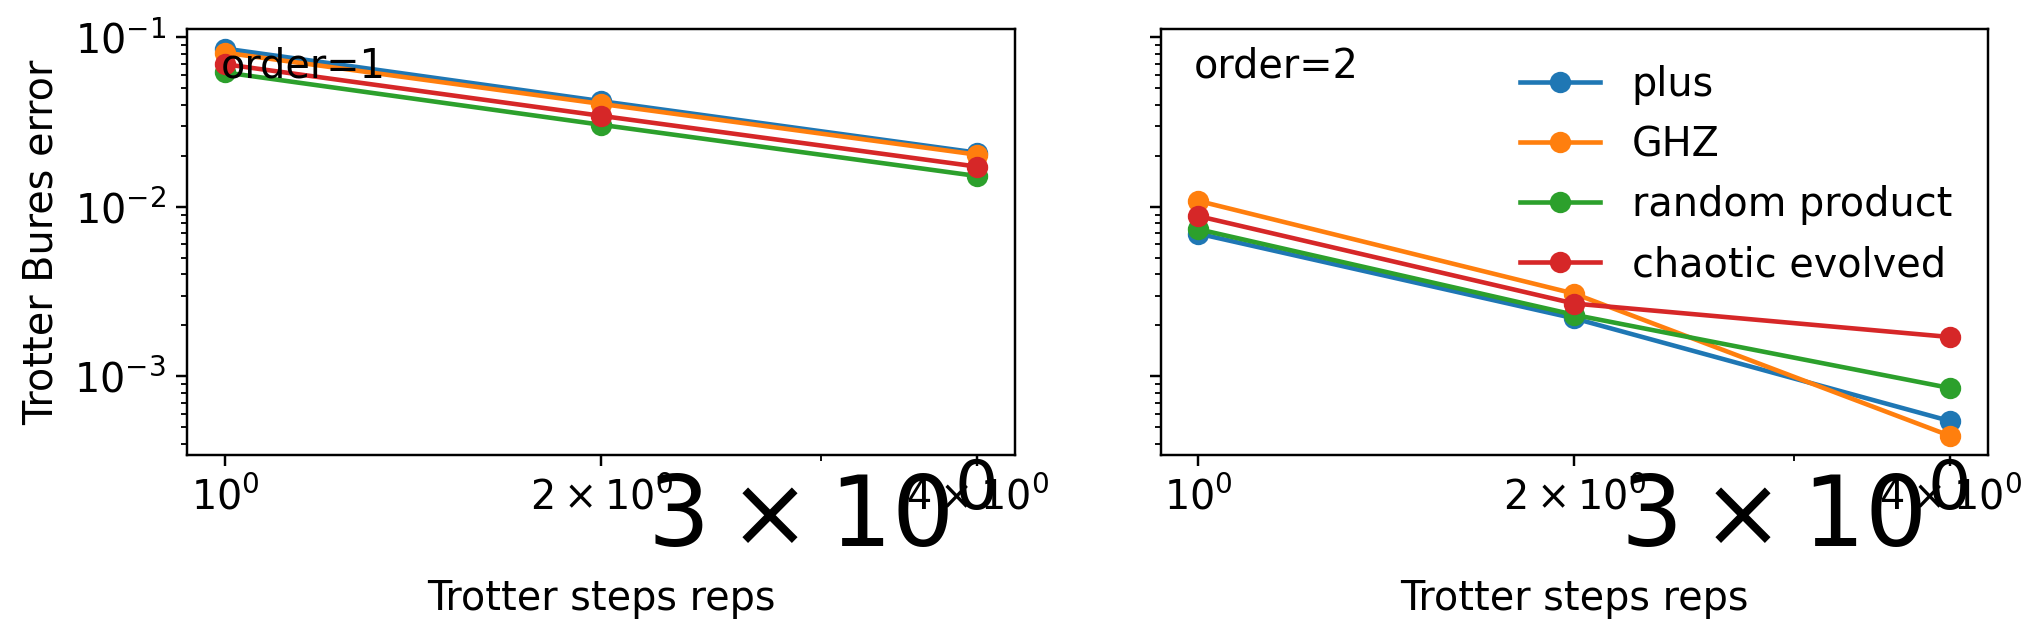

In [ ]:
fig, axes = plt.subplots(1, len(orders), figsize=(5.0 * len(orders), 3.6), sharey=True)
if len(orders) == 1:
    axes = [axes]

for order_index, (order, ax) in enumerate(zip(orders, axes)):
    for state_index, label in enumerate(state_labels):
        ax.loglog(reps, trotter_error[order_index, state_index], marker="o", label=str(label))
    ax.set_xlabel("Trotter steps reps",fontsize=13)
    ax.text(0.04, 0.96, f"order={order}", transform=ax.transAxes, ha="left", va="top", fontsize=13)
    ax.xaxis.set_major_formatter(plt.ScalarFormatter())
    ax.set_xticks(reps)
    ax.tick_params(axis="both", which="major", labelsize=13)
axes[0].set_ylabel("Trotter Bures error",fontsize=13)
axes[-1].legend(frameon=False,fontsize=13)
fig.tight_layout()

## QFI Prediction Versus Trotter Error

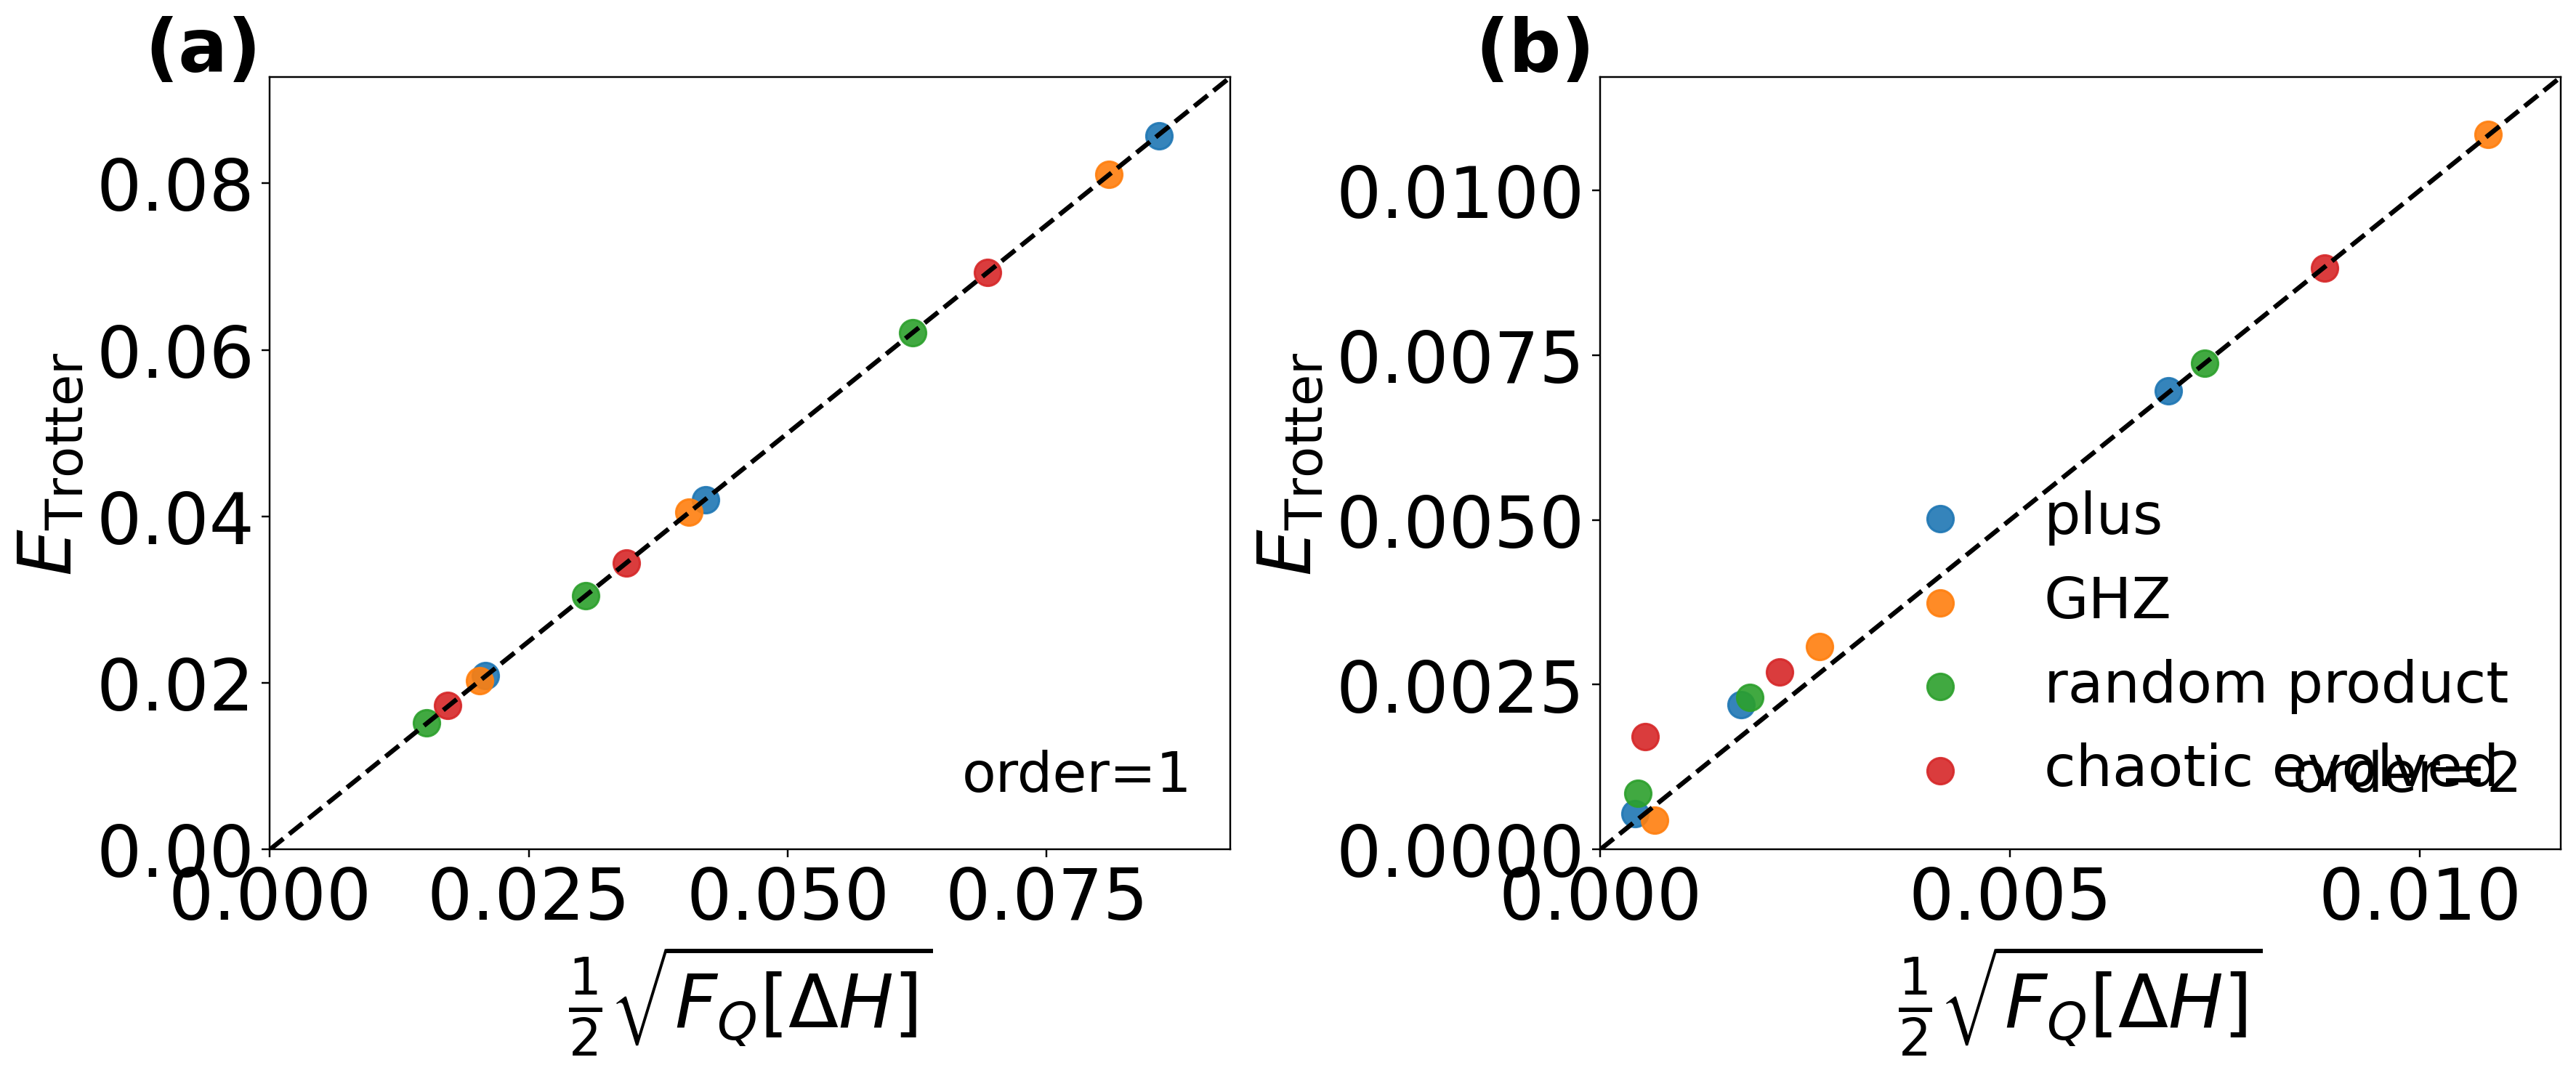

In [4]:
fig, axes = plt.subplots(1, len(orders), figsize=(16.0, 6.6), sharex=False, sharey=False, constrained_layout=True)
if len(orders) == 1:
    axes = [axes]

for order_index, (order, ax) in enumerate(zip(orders, axes)):
    x = qfi_error[order_index].ravel()
    y = trotter_error[order_index].ravel()
    labels = np.repeat(state_labels, len(reps))
    for label in state_labels:
        mask = labels == label
        ax.scatter(x[mask], y[mask], label=str(label), alpha=0.9, s=140)
    lim = max(np.nanmax(x), np.nanmax(y)) * 1.08
    ax.plot([0, lim], [0, lim], color="black", lw=2.1, ls="--")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel(r"$\frac{1}{2}\sqrt{F_Q[\Delta H]}$")
    ax.set_ylabel(r"$E_{\mathrm{Trotter}}$")
    ax.tick_params(axis="both", which="major", labelsize=32)
    ax.text(-0.13, 1.08, f"({chr(97 + order_index)})", transform=ax.transAxes, ha="left", va="top", fontsize=33, fontweight="bold", clip_on=False)
    ax.text(0.96, 0.06, f"order={order}", transform=ax.transAxes, ha="right", va="bottom", fontsize=25)
axes[-1].legend(frameon=False, loc="lower right")
fig.savefig(FIGURE_DIR / "trotter_tradeoff.pdf", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "trotter_tradeoff.png", bbox_inches="tight")

## Ratio

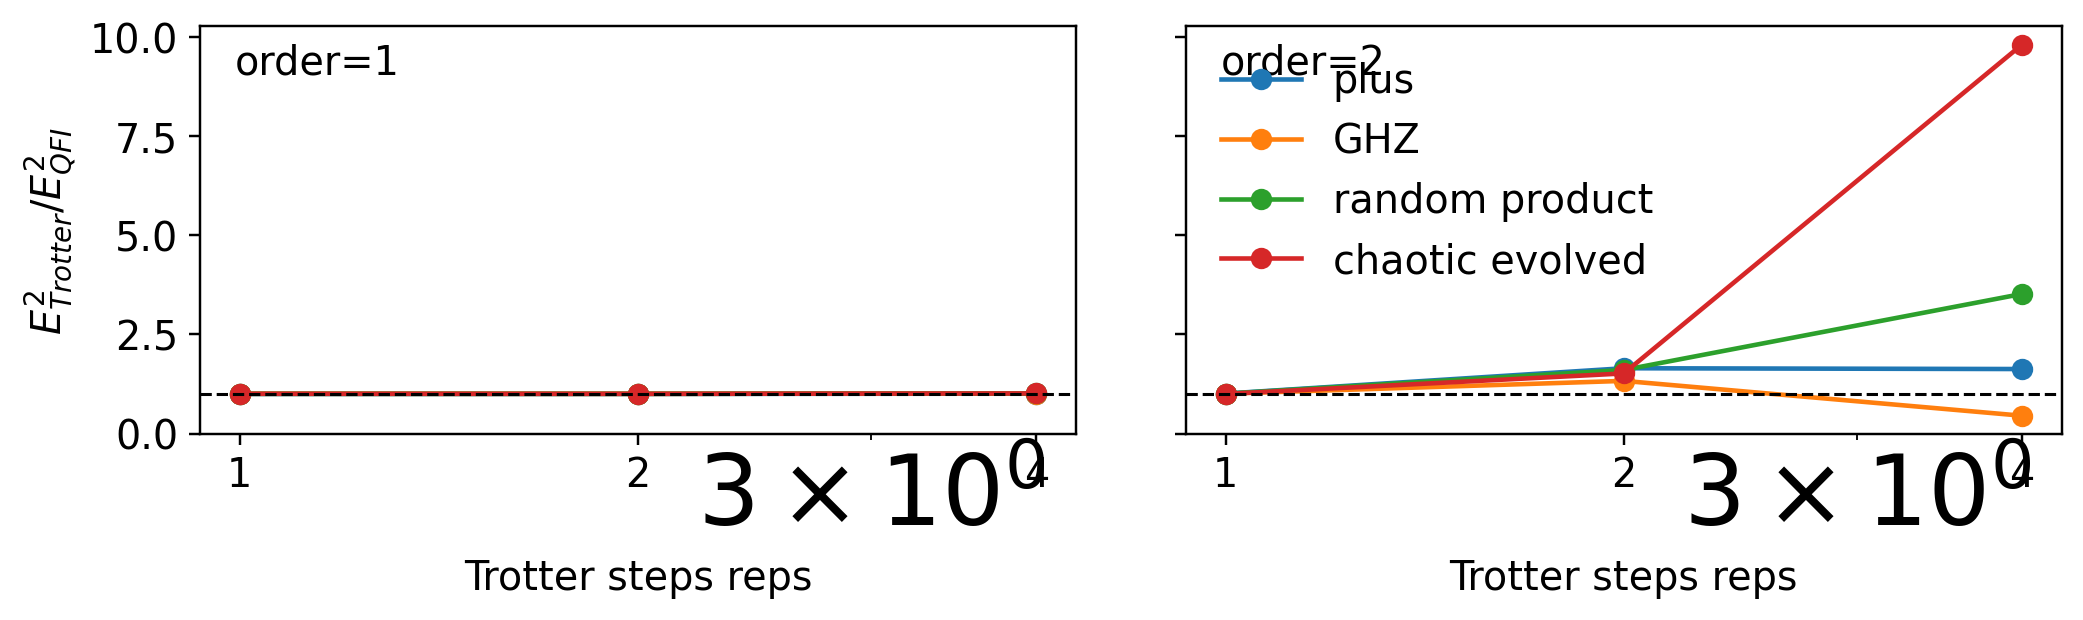

In [15]:
fig, axes = plt.subplots(1, len(orders), figsize=(5.0 * len(orders), 3.5), sharey=True)
if len(orders) == 1:
    axes = [axes]

for order_index, (order, ax) in enumerate(zip(orders, axes)):
    for state_index, label in enumerate(state_labels):
        ax.semilogx(reps, ratio[order_index, state_index], marker="o", label=str(label))
    ax.axhline(1.0, color="black", lw=1, ls="--")
    ax.set_xlabel("Trotter steps reps", fontsize=13)
    ax.text(0.04, 0.96, f"order={order}", transform=ax.transAxes, ha="left", va="top", fontsize=13)
    ax.xaxis.set_major_formatter(plt.ScalarFormatter())
    ax.set_xticks(reps)
    ax.tick_params(axis="both", which="major", labelsize=13)
axes[0].set_ylabel(r"$E_{Trotter}^2 / E_{QFI}^2$", fontsize=13)
axes[-1].legend(frameon=False, fontsize=13)
fig.tight_layout()